In [1]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from wordcloud import WordCloud

fission = "http://localhost:9090"

In [8]:
def format_date(date):
    return date.strftime("%Y-%m-%d")

def dataframe(data, start):
    base = datetime.datetime.today()
    num_days = (base - datetime.datetime.fromisoformat(start)).days
    date_list = [format_date(base - datetime.timedelta(days=x)) for x in range(num_days, -1, -1)]
    df = pd.DataFrame.from_dict(data, orient="index").reindex(date_list)
    return df

In [35]:
start_date = "2024-11-01"
response = requests.get(
        url=f"{fission}/ui/sentiment/start/{start_date}/keyword/*",
        timeout=120
    )

print(response)
keys = ["bluesky", "reddit", "openaus"]
data = response.json()
df = {}
for s in keys:
    df[s] = dataframe(data[s], start_date)

<Response [200]>


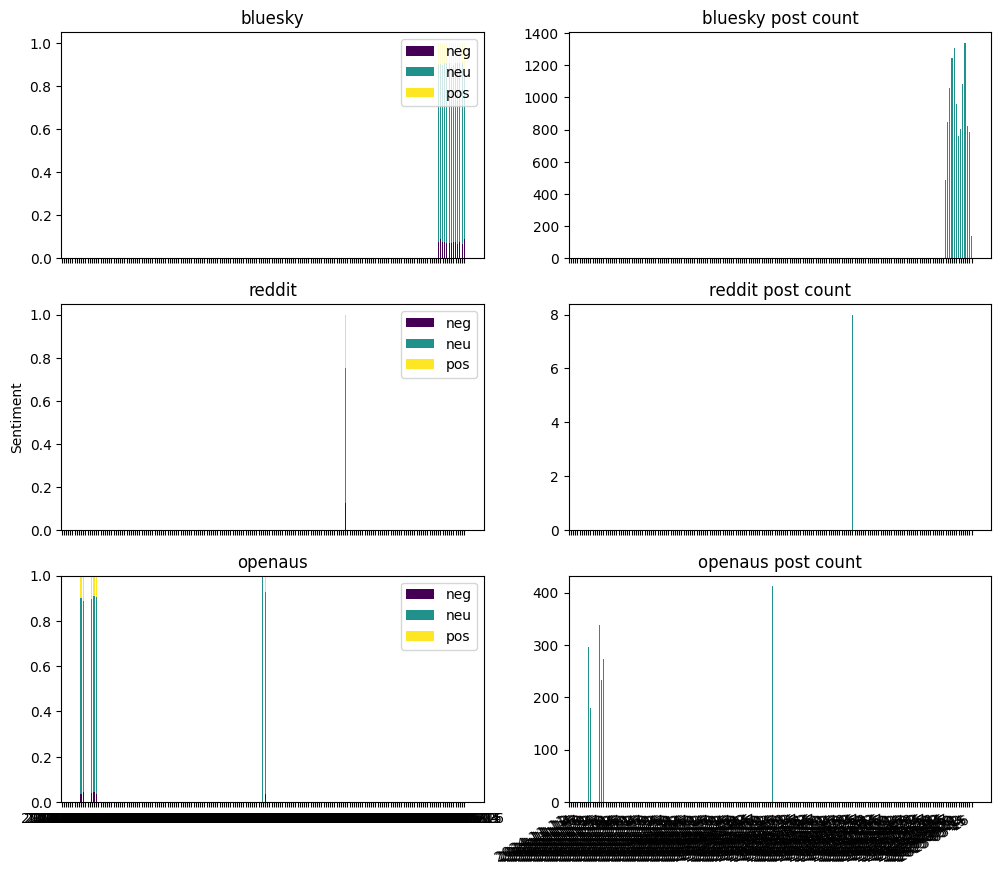

In [36]:
# colors
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, 3))

# plot
fig, ax = plt.subplots(3, 2, sharex=True, figsize=(12, 10))
ax[int(len(keys) / 2),0].set_ylabel("Sentiment", loc="center")

bottom = np.zeros(len(df["bluesky"]["neg"]))
for i, s in enumerate(keys):
    temp_df = df[s]
    total = temp_df['neg'] + temp_df['neu'] + temp_df['pos']
    bottom = np.zeros(len(temp_df["neg"]))

    for j, col in enumerate(['neg', 'neu', 'pos']):
        ax[i,0].bar(temp_df.index, temp_df[col] / total, 0.5, label=col, color=colors[j], bottom=bottom)
        bottom += temp_df[col] / total
    
    ax[i,0].legend(loc="upper right")
    ax[i,0].set_title(s)
    ax[i,0].set_ylim(bottom=0)

    ax[i, 1].bar(temp_df.index, total, 0.5, label=col, color=colors[1])
    ax[i,1].set_title(s + " post count")
    ax[i,1].set_ylim(bottom=0)

plt.xticks(rotation=30, ha='right')
plt.show()

In [ ]:
response = requests.get(
        url=f"{fission}/ui/named-entities/count/100/label/ORG",
        timeout=600
    )

print(response)
data = response.json()

for s in ["bluesky"]:
    wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(s + " - org")
    plt.show()

In [ ]:
response = requests.get(
        url=f"{fission}/ui/named-entities/count/100/label/LOC",
        timeout=600
    )

print(response)
data = response.json()

for s in ["bluesky"]:
    wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(s + " - loc")
    plt.show()

In [ ]:
response = requests.get(
        url=f"{fission}/ui/named-entities/count/100/label/PERSON",
        timeout=600
    )

print(response)
data = response.json()

for s in ["bluesky"]:
    wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(s + " - person")
    plt.show()